<a href="https://colab.research.google.com/github/Shree1785/CSL701-CE49-Machine-Learning-Lab/blob/main/Experiments/ML_Experiment_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Bhagyashree Shrikrishna Wagle

Batch : CE3

Roll Number : CE49



Machine Learning Experiment No. 7

Aim

To implement Principal Component Analysis (PCA) for dimensionality reduction on the Breast Cancer Wisconsin (Diagnostic) dataset, visualize the high-dimensional feature space in a reduced 2D plane, and evaluate its impact on classification performance.

## Objectives

1. To understand the concepts of dimensionality reduction, feature correlation, and Principal Component Analysis.

2. To preprocess, clean, and scale high-dimensional real-world data using StandardScaler.

3. To implement PCA using Python to compress feature dimensions from 30 continuous features down to 2 principal components.

4. To calculate and plot the explained variance ratio and cumulative explained variance.

5. To visualize the transformed 2D dataset and analyze class separability.

6. To evaluate and compare classification model performance (e.g., Logistic Regression) before and after applying PCA.

# Relevant Theory

### Support Vector Machine

Principal Component Analysis (PCA)Principal Component Analysis (PCA) is an unsupervised machine learning technique used for dimensionality reduction. It transforms a dataset containing a large set of correlated features into a smaller set of uncorrelated variables called Principal Components ($PCs$), while preserving as much data variance as possible.

Mathematical Steps:

1. Standardization: Scale each feature to have a mean of 0 ($\mu = 0$) and standard deviation of 1 ($\sigma = 1$).

2. Covariance Matrix: Compute the covariance matrix $C$ to quantify feature correlations:$$C = \frac{1}{n-1} X^T X$$

3. Eigen decomposition: Compute eigenvalues ($\lambda$) and eigenvectors ($v$) of matrix $C$:$$C v = \lambda v$$

    * Eigenvectors represent the direction of the principal axes.
    * Eigenvalues indicate the amount of variance along those axes.
4. Projection: Project original data $X$ onto top $k$ principal component directions $W$:$$X_{\text{pca}} = X \cdot W$$

###Dataset Information


1. Dataset Name: Breast Cancer Wisconsin (Diagnostic) Dataset

2. Kaggle Link: https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data

3. Classes: 2 binary classes (Malignant [$M$] and Benign [$B$])

4. Features: 30 continuous features computed from digitized images of fine needle aspirates (FNA) of a breast mass (e.g., radius_mean, texture_mean, perimeter_mean, area_mean, smoothness_mean, concavity_mean, etc.).

5. Non-Feature Columns: id (identifier) and Unnamed: 32 (empty column).

# Task 1: Import Libraries and Load Dataset

Import core Python libraries (numpy, pandas, matplotlib, seaborn, sklearn) and load data.csv obtained from Kaggle.

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
data = pd.read_csv("data.csv")

print("Dataset loaded successfully.")
print("Dataset Shape:", data.shape)

data.head()

Dataset loaded successfully.
Dataset Shape: (569, 33)


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


# Task 2: Explore the Dataset

Inspect missing values, view dataset summary statistics, check column data types, and inspect target class distributions (diagnosis).

Missing Values:
id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst

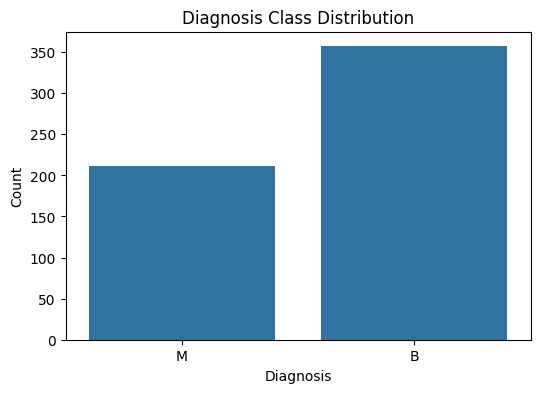

In [ ]:
# Check missing values
print("Missing Values:")
print(data.isnull().sum())

# Summary statistics
print("\nSummary Statistics:")
print(data.describe())

# Check data types
print("\nData Types:")
print(data.dtypes)

# Check target class distribution
print("\nDiagnosis Class Distribution:")
print(data["diagnosis"].value_counts())

# Plot class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x="diagnosis")
plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Count")
plt.show()

# Task 3: Data Cleaning and Feature/Target Selection

Drop metadata columns (id and Unnamed: 32). Convert the categorical target column (diagnosis: 'M'/'B') into numerical values (1/0) and separate feature matrix $X$ (30 features) from label vector $y$.   

In [ ]:
# Drop metadata columns
data = data.drop(columns=["id", "Unnamed: 32"], errors="ignore")

# Convert diagnosis into numerical values
# M = Malignant = 1
# B = Benign = 0
data["diagnosis"] = data["diagnosis"].map({
    "M": 1,
    "B": 0
})

# Separate features and target
X = data.drop(columns=["diagnosis"])
y = data["diagnosis"]

# Convert features to numeric
X = X.apply(pd.to_numeric, errors="coerce")

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nNumber of Features:", X.shape[1])

print("\nTarget Distribution:")
print(y.value_counts())

Feature Matrix Shape: (569, 30)
Target Shape: (569,)

Number of Features: 30

Target Distribution:
diagnosis
0    357
1    212
Name: count, dtype: int64


# Task 4: Standardize Features

Apply StandardScaler to transform all 30 numeric features so they have zero mean and unit variance ($\mu=0, \sigma=1$).

In [ ]:
# Create StandardScaler
scaler = StandardScaler()

# Standardize all 30 features
X_scaled = scaler.fit_transform(X)

print("Scaled Data Shape:", X_scaled.shape)

print("\nMean of first 5 features:")
print(X_scaled[:, :5].mean(axis=0))

print("\nStandard Deviation of first 5 features:")
print(X_scaled[:, :5].std(axis=0))

Scaled Data Shape: (569, 30)

Mean of first 5 features:
[-1.37363271e-16  6.86816353e-17 -1.24875700e-16 -2.18532476e-16
 -8.36667193e-16]

Standard Deviation of first 5 features:
[1. 1. 1. 1. 1.]


# Task 5: Implement PCA (30D to 2D)

Use sklearn.decomposition.PCA to reduce feature dimensions from 30 down to 2 principal components ($PC_1$ and $PC_2$).

In [ ]:
# Create PCA with 2 components
pca = PCA(n_components=2)

# Transform the standardized data
X_pca = pca.fit_transform(X_scaled)

print("Original Number of Features:", X_scaled.shape[1])
print("Reduced Number of Features:", X_pca.shape[1])

print("PCA Transformed Data Shape:", X_pca.shape)

Original Number of Features: 30
Reduced Number of Features: 2
PCA Transformed Data Shape: (569, 2)


# Task 6: Analyze Explained Variance Ratio

Compute and print the variance explained by $PC_1$ and $PC_2$, along with the cumulative variance retained.


Variance Explained by PC1: 44.27 %
Variance Explained by PC2: 18.97 %
Cumulative Variance Retained: 63.24 %


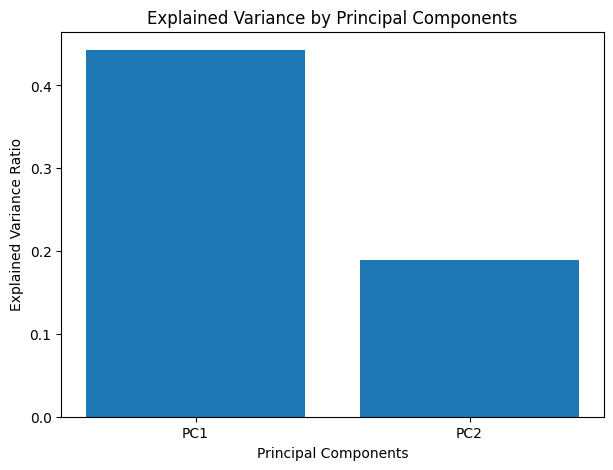

In [ ]:
# Get explained variance ratio
explained_variance = pca.explained_variance_ratio_

# Variance explained by each component
pc1_variance = explained_variance[0]
pc2_variance = explained_variance[1]

# Cumulative variance
cumulative_variance = explained_variance.sum()

print("Variance Explained by PC1:",
      round(pc1_variance * 100, 2), "%")

print("Variance Explained by PC2:",
      round(pc2_variance * 100, 2), "%")

print("Cumulative Variance Retained:",
      round(cumulative_variance * 100, 2), "%")

# Plot explained variance
plt.figure(figsize=(7, 5))

plt.bar(
    ["PC1", "PC2"],
    explained_variance
)

plt.xlabel("Principal Components")
plt.ylabel("Explained Variance Ratio")
plt.title("Explained Variance by Principal Components")

plt.show()

# Task 7: Visualize PCA Transformed Boundary / Scatter Plot

Create a 2D scatter plot with $PC_1$ on the x-axis and $PC_2$ on the y-axis, hue-coded by tumor diagnosis (Malignant vs. Benign).

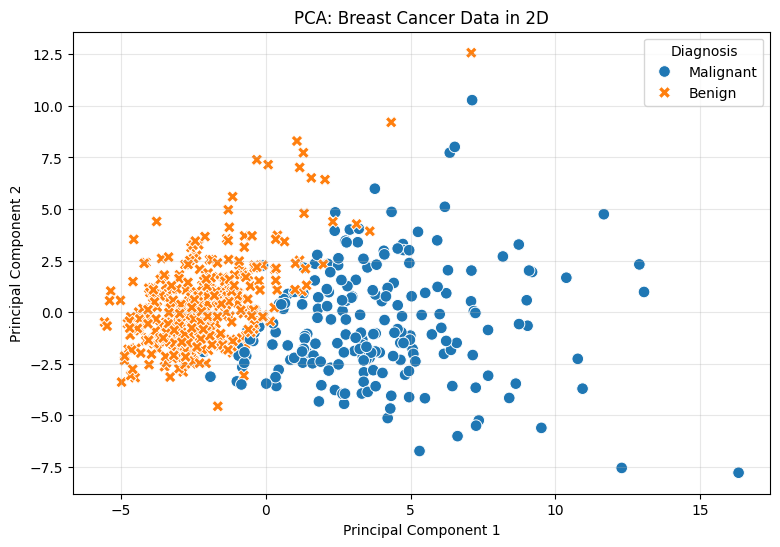

In [ ]:
# Create DataFrame containing PCA components
pca_data = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Diagnosis": y.map({
        0: "Benign",
        1: "Malignant"
    })
})

# Create scatter plot
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=pca_data,
    x="PC1",
    y="PC2",
    hue="Diagnosis",
    style="Diagnosis",
    s=70
)

plt.title("PCA: Breast Cancer Data in 2D")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.legend(title="Diagnosis")
plt.grid(alpha=0.3)

plt.show()

# Task 8: Train Classifier on Raw High-Dimensional Data (30 Features)

Split the original scaled 30-feature dataset into training and testing sets. Train a Logistic Regression model and obtain baseline performance metrics.

In [ ]:
# Split original 30-feature standardized data
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_scaled,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
logreg_raw = LogisticRegression(max_iter=1000)

# Train the model
logreg_raw.fit(X_train_raw, y_train_raw)

# Make predictions
y_pred_raw = logreg_raw.predict(X_test_raw)

# Calculate accuracy
raw_accuracy = accuracy_score(
    y_test_raw,
    y_pred_raw
)

print("Baseline Accuracy (30 Features):",
      round(raw_accuracy * 100, 2), "%")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_raw, y_pred_raw))

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test_raw,
        y_pred_raw,
        target_names=["Benign", "Malignant"]
    )
)

Baseline Accuracy (30 Features): 96.49 %

Confusion Matrix:
[[71  1]
 [ 3 39]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



# Task 9: Train Classifier on PCA Transformed Data (2 Features)

Split the 2-component PCA dataset into training and testing sets. Train a Logistic Regression model using only $PC_1$ and $PC_2$.

In [ ]:
# Split PCA transformed data
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Create Logistic Regression model
logreg_pca = LogisticRegression(max_iter=1000)

# Train the model
logreg_pca.fit(X_train_pca, y_train_pca)

# Make predictions
y_pred_pca = logreg_pca.predict(X_test_pca)

# Calculate accuracy
pca_accuracy = accuracy_score(
    y_test_pca,
    y_pred_pca
)

print("PCA Accuracy (2 Components):",
      round(pca_accuracy * 100, 2), "%")

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test_pca, y_pred_pca))

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test_pca,
        y_pred_pca,
        target_names=["Benign", "Malignant"]
    )
)

PCA Accuracy (2 Components): 93.86 %

Confusion Matrix:
[[71  1]
 [ 6 36]]

Classification Report:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



# Task 10: Compare Classifier Performance

Compare the performance of the model before PCA (30 features) vs. after PCA (2 components) using:   

*   Accuracy Score
*   Confusion Matrix
*   Classification Report (Precision, Recall, F1-Score)  



Accuracy Comparison:


,Model,Accuracy
0,Logistic Regression - 30 Features,0.964912
1,Logistic Regression - 2 PCA Components,0.938596



Confusion Matrix - Before PCA:
[[71  1]
 [ 3 39]]

Confusion Matrix - After PCA:
[[71  1]
 [ 6 36]]

Classification Report - Before PCA:
              precision    recall  f1-score   support

      Benign       0.96      0.99      0.97        72
   Malignant       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114


Classification Report - After PCA:
              precision    recall  f1-score   support

      Benign       0.92      0.99      0.95        72
   Malignant       0.97      0.86      0.91        42

    accuracy                           0.94       114
   macro avg       0.95      0.92      0.93       114
weighted avg       0.94      0.94      0.94       114



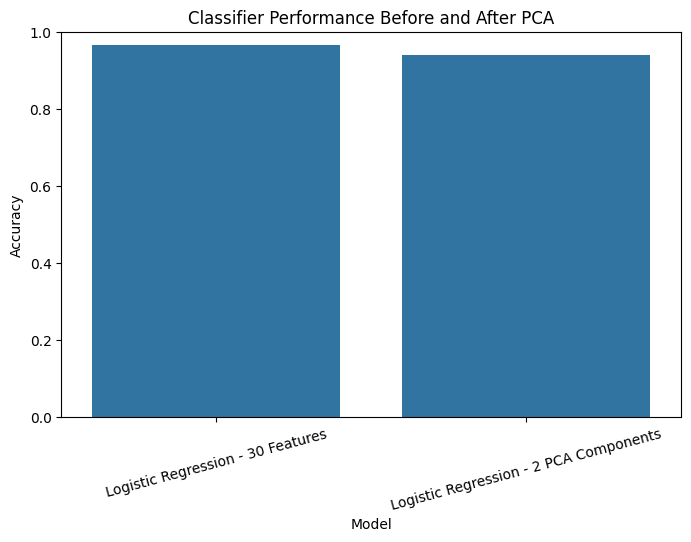

In [ ]:
# Calculate confusion matrices
raw_cm = confusion_matrix(
    y_test_raw,
    y_pred_raw
)

pca_cm = confusion_matrix(
    y_test_pca,
    y_pred_pca
)

# Create comparison table
comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression - 30 Features",
        "Logistic Regression - 2 PCA Components"
    ],
    "Accuracy": [
        raw_accuracy,
        pca_accuracy
    ]
})

print("Accuracy Comparison:")
display(comparison)

# Confusion Matrix before PCA
print("\nConfusion Matrix - Before PCA:")
print(raw_cm)

# Confusion Matrix after PCA
print("\nConfusion Matrix - After PCA:")
print(pca_cm)

# Classification Report before PCA
print("\nClassification Report - Before PCA:")
print(
    classification_report(
        y_test_raw,
        y_pred_raw,
        target_names=["Benign", "Malignant"]
    )
)

# Classification Report after PCA
print("\nClassification Report - After PCA:")
print(
    classification_report(
        y_test_pca,
        y_pred_pca,
        target_names=["Benign", "Malignant"]
    )
)

# Accuracy comparison graph
plt.figure(figsize=(8, 5))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.ylim(0, 1)
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Classifier Performance Before and After PCA")

plt.xticks(rotation=15)

plt.show()

# Conclusion

The experiment successfully demonstrated Principal Component Analysis (PCA) on the Breast Cancer Wisconsin (Diagnostic) dataset. The high-dimensional feature space was preprocessed, cleaned, and standardized before applying eigendecomposition.

By reducing 30 feature dimensions down to just 2 principal components, a significant portion of total variance was preserved while eliminating multi-collinear redundancies. Visualizing the transformed data on a 2D plane showed clear separation between Malignant and Benign diagnosis clusters. Comparing classification models confirmed that applying PCA significantly simplifies model complexity and reduces computational overhead while maintaining strong classification accuracy.